In [166]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from scipy import ndimage
from scipy.stats import mode
import traceback

In [167]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [168]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8

=== Level: medium ===
30.png                shape=(204, 890, 3)  dtype=uint8
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8


In [169]:
def get_canny_edges_auto(grey, sigma=0.33, debug=True, title="Canny Edges (Auto)"):

    # Estimate noise level using median
    v = np.median(grey)

    # Automatic thresholds
    low  = int(max(0, (1.0 - sigma) * v))
    high = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(grey, low, high)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(edges, cmap="gray")
        plt.title(f"{title} (low={low}, high={high})")
        plt.axis("off")

    return edges


In [170]:


available_images = {
    "easy": [
        "29.png",
        "not_that_easy.jpg",
        "easy.jpg",
        "20.png",
    ],
    "medium": [
        "12.png",
        "30.png",
        "31.png",
    ],
    "hard": [
        "21.png",
        "frame600.jpg",
        "frame1.jpg",
    ]
}

loaded_images = {}

for set_name, file_list in available_images.items():
    loaded_images[set_name] = {}
    
    for fname in file_list:
        path = os.path.join("images", set_name, fname)
        img = cv2.imread(path)

        if img is None:
            print(f"⚠️ Could not load image: {path}")
        else:
            loaded_images[set_name][fname] = img
            print(f"Loaded {path}   shape={img.shape}")

# --- EASY
#(set_name, image_name) = ("easy", "29.png")           # the cartoonish one
#(set_name, image_name) = ("easy", "not_that_easy.jpg") # the fake cars ones with the concrete lines.
#(set_name, image_name) = ("easy", "easy.jpg")         # fake empty one with the bits of lines at the bottom
#(set_name, image_name) = ("easy", "20.png")           # The mirror one, real cars

# --- MEDIUM
#(set_name, image_name) = ("medium", "12.png")  # the one with the grass dividers on either side
#(set_name, image_name) = ("medium", "30.png")  # slightly askew lines
#(set_name, image_name) = ("medium", "31.png")  # top and bottom rows.

# --- HARD
#(set_name, image_name) = ("hard", "frame600.jpg") # dangan crop
# (set_name, image_name) = ("hard", "frame1.jpg")   # dangan large
#(set_name, image_name) = ("hard", "21.png")       # the rotated image

# print(f"{image_name} from the {set_name} set")
# img = images[set_name][image_name]
# image = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
# plt.figure(figsize=(8, 8))
# plt.imshow(img)
# plt.title(f"{image_name} from {set_name}")
# plt.axis("off")

Loaded images/easy/29.png   shape=(318, 477, 3)
Loaded images/easy/not_that_easy.jpg   shape=(433, 612, 3)
Loaded images/easy/easy.jpg   shape=(459, 612, 3)
Loaded images/easy/20.png   shape=(630, 1200, 3)
Loaded images/medium/12.png   shape=(1080, 1920, 3)
Loaded images/medium/30.png   shape=(204, 890, 3)
Loaded images/medium/31.png   shape=(827, 1412, 3)
Loaded images/hard/21.png   shape=(733, 1100, 3)
Loaded images/hard/frame600.jpg   shape=(2160, 3840, 3)
Loaded images/hard/frame1.jpg   shape=(2160, 3840, 3)


In [171]:
def print_pics(images_dict, cmap=None):
    if not images_dict:
        print("No images to display.")
        return

    difficulties = sorted(images_dict.keys())

    max_cols = max(len(v) for v in images_dict.values())
    fig, axes = plt.subplots(
        nrows=len(difficulties),
        ncols=max_cols,
        figsize=(3 * max_cols, 3 * len(difficulties))
    )

    if len(difficulties) == 1:
        axes = [axes]
    elif axes.ndim == 1:
        axes = [axes]

    for row_idx, diff in enumerate(difficulties):
        imgs = images_dict[diff]

        sorted_imgs = dict(sorted(imgs.items()))

        for col_idx, (img_name, img) in enumerate(sorted_imgs.items()):
            ax = axes[row_idx][col_idx]
            ax.imshow(img, cmap=cmap)
            ax.set_title(img_name, fontsize=8)
            ax.axis("off")

        for empty_ax in axes[row_idx][len(sorted_imgs):]:
            empty_ax.axis("off")

        axes[row_idx][0].set_ylabel(diff, rotation=0, size='large', labelpad=40, weight='bold')

    plt.tight_layout()
    plt.show()


In [172]:
def step_1(input_image, is_aligned=False, debug=False):
    img_grey = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(img_grey, (3,21), 0) 

    canny_output = get_canny_edges_auto(blurred, debug=debug)

    
    return canny_output, img_grey

In [173]:
def cluster_vertical_lines(lines, distance_thresh=20):
    """
    Takes Hough lines and merges vertical-ish lines into averaged lines.
    distance_thresh: max |rho difference| allowed in the same cluster.
    Preserves the actual slanted angle instead of forcing theta = 0.
    """
    vertical_rhos = []
    vertical_thetas = []

    # Extract vertical-ish lines
    for line in lines:
        rho, theta = line

        # Allow angles within ±20° of vertical
        if theta < np.deg2rad(50) or theta > np.deg2rad(160):
            vertical_rhos.append(rho)
            vertical_thetas.append(theta)

    if not vertical_rhos:
        return []

    # Sort by rho
    idx = np.argsort(vertical_rhos)
    rhos_sorted = np.array(vertical_rhos)[idx]
    thetas_sorted = np.array(vertical_thetas)[idx]

    clusters = []
    current_rhos = [rhos_sorted[0]]
    current_thetas = [thetas_sorted[0]]

    for r, t in zip(rhos_sorted[1:], thetas_sorted[1:]):
        if abs(r - current_rhos[-1]) < distance_thresh:
            current_rhos.append(r)
            current_thetas.append(t)
        else:
            clusters.append((current_rhos, current_thetas))
            current_rhos = [r]
            current_thetas = [t]

    clusters.append((current_rhos, current_thetas))

    # Average lines in each cluster
    merged = []
    for rhos, thetas in clusters:
        avg_rho = np.mean(rhos)

        # Normalise angles first so they average correctly
        thetas_norm = [normalise_angle(t) for t in thetas]
        avg_theta_norm = np.mean(thetas_norm)

        # Convert back to full range (0 to pi)
        if avg_theta_norm < 0:
            avg_theta = avg_theta_norm + np.pi
        else:
            avg_theta = avg_theta_norm

        merged.append((avg_rho, avg_theta))

    return merged

In [174]:
def normalise_angle(theta):
    # Convert to orientation angle (0–π) but symmetric
    return theta if theta < np.pi/2 else theta - np.pi

In [175]:
def modal_angle(angles, bin_size_deg=2):
    if len(angles) == 0:
        return None

    bin_size = np.deg2rad(bin_size_deg)
    bins = np.arange(-np.pi/2, np.pi/2 + bin_size, bin_size)

    hist, edges = np.histogram(angles, bins=bins)
    idx = np.argmax(hist)

    # modal angle = center of bin
    modal = (edges[idx] + edges[idx + 1]) / 2
    return modal


In [176]:
def filter_by_modal_angle(lines, angle_tolerance_deg=5):
    """
    lines: list of (rho, theta, x1, y1, x2, y2)
    
    Returns:
        filtered_lines: lines whose angle matches the modal cluster
        weighted_mean_angle: weighted average angle (radians),
                             weight = line segment length
    """
    if not lines:
        return [], None

    # Extract normalized angles
    angs = [normalise_angle(theta) for (rho, theta, *_rest) in lines]

    # Find modal orientation
    modal = modal_angle(angs)
    if modal is None:
        return [], None

    tol = np.deg2rad(angle_tolerance_deg)

    # First filter lines based on modal cluster
    filtered = []
    lengths = []
    angles = []

    for (rho, theta, x1, y1, x2, y2) in lines:
        ang = normalise_angle(theta)
        if abs(ang - modal) < tol:
            filtered.append((rho, theta, x1, y1, x2, y2))

            # compute length for weighting
            length = np.hypot(x2 - x1, y2 - y1)
            lengths.append(length)
            angles.append(ang)

    if not filtered:
        return [], None

    # Compute weighted mean angle (circular!)
    # using unit vectors (cos, sin)
    angles = np.array(angles)
    lengths = np.array(lengths)

    mean_cos = np.sum(lengths * np.cos(angles)) / np.sum(lengths)
    mean_sin = np.sum(lengths * np.sin(angles)) / np.sum(lengths)

    weighted_mean_angle = np.arctan2(mean_sin, mean_cos)

    return filtered, weighted_mean_angle


In [177]:
def line_to_rho_theta(x1, y1, x2, y2):
    angle = np.arctan2((y2 - y1), (x2 - x1))
    theta = angle + np.pi/2

    # midpoint of the segment
    x0 = (x1 + x2) / 2
    y0 = (y1 + y2) / 2

    rho = x0 * np.cos(theta) + y0 * np.sin(theta)

    return rho, theta


In [178]:
def step_2(canny_input, image, downsample=False, scale=0.5, debug=False):
    # Copy image for drawing
    if downsample:
        image = cv2.resize(image, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
        canny_input = cv2.resize(canny_input, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

    # Hough transform (probabilistic)
    linesP = cv2.HoughLinesP(
        canny_input,
        rho=1,
        theta=np.pi/180,
        threshold=50,
        minLineLength=40,
        maxLineGap=15
    )
    
    # Copy image for drawing
    houghP_vis = image.copy()
    
    # Draw detected segments
    if debug:
        if linesP is not None:
            for (x1, y1, x2, y2) in linesP[:,0]:
                cv2.line(houghP_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        plt.figure(figsize=(8, 8))
        plt.imshow(houghP_vis)
        plt.title("Raw HoughLinesP Segments")
        plt.axis("off")

    return linesP

#linesP = step_2(canny_output, image)

In [179]:
def step_3(linesP, image, horiz_thresh=45, angle_tolerance_deg=20, debug=False):
    
    hough_lines = image.copy()
    
    horiz_center = np.pi / 2
    horiz_thresh = np.deg2rad(horiz_thresh)
    
    non_horiz = []
    
    if linesP is not None:
        for (x1, y1, x2, y2) in linesP[:,0]:
            rho, theta = line_to_rho_theta(x1, y1, x2, y2)
    
            # apply same horizontal filtering
            if abs(theta - horiz_center) >= horiz_thresh:
                # store full segment
                non_horiz.append((rho, theta, x1, y1, x2, y2))
    
    # Filter by modal angle (but keep original segments)
    filtered_lines, modal_angle_of_image = filter_by_modal_angle(non_horiz, angle_tolerance_deg=angle_tolerance_deg)
    
    # Draw filtered segments (NOT infinite lines)
    hough_lines = image.copy()

    if debug:
        for (rho, theta, x1, y1, x2, y2) in filtered_lines:
            cv2.line(hough_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

        plt.figure(figsize=(8, 8))
        plt.imshow(hough_lines)
        plt.title("Filtered HoughLinesP Segments (Modal Angle)")
        plt.axis("off")
    
        print(f"Modal Angle: {modal_angle_of_image}")
    
    return filtered_lines, modal_angle_of_image

#first_filtered_lines, modal_angle_of_image = step_3(linesP, image)


In [180]:
def rotate_image_nocrop(image, angle_deg, threshold_deg=10, debug=False):
    """
    Rotate an image around its center without cropping.
    If |angle| < threshold_deg, no rotation is applied.
    Returns (rotated_image, affine_matrix M).
    """
    # Skip rotation if angle is small
    if abs(angle_deg) < threshold_deg:
        if debug:
            print(f"Not Rotating, {angle_deg} degree angle")
        M = None
        return image.copy(), M

    (h, w) = image.shape[:2]
    center = (w / 2, h / 2)

    # Rotation matrix
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)

    # Compute new bounding box
    cos = np.abs(M[0, 0])
    sin = np.abs(M[0, 1])

    new_w = int(h * sin + w * cos)
    new_h = int(h * cos + w * sin)

    # Adjust translation
    M[0, 2] += (new_w / 2) - center[0]
    M[1, 2] += (new_h / 2) - center[1]

    # Rotate with reflection padding
    rotated = cv2.warpAffine(
        image, M, (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_REFLECT_101
    )

    return rotated, M

def rotate_points_step_4(segments, M):
    """
    Rotate a list of line segments using affine matrix M and always return
    (rho, theta, x1, y1, x2, y2).

    segments may be:
        - (x1, y1, x2, y2)
        - (rho, theta, x1, y1, x2, y2)

    If M is None:
        - DO NOT rotate
        - BUT still recompute (rho, theta) for every segment
    """

    rotated_no_rt = []
    
    for seg in segments:

        # ----- extract endpoints only -----
        if len(seg) == 6:
            _, _, x1, y1, x2, y2 = seg
        elif len(seg) == 4:
            x1, y1, x2, y2 = seg
        else:
            raise ValueError(f"Invalid segment length {len(seg)}: {seg}")

        if M is not None:
            # Rotate using affine matrix
            p1 = M @ np.array([x1, y1, 1.0])
            p2 = M @ np.array([x2, y2, 1.0])

            x1r = int(round(p1[0]))
            y1r = int(round(p1[1]))
            x2r = int(round(p2[0]))
            y2r = int(round(p2[1]))
        else:
            # No rotation: keep original coordinates
            x1r, y1r, x2r, y2r = x1, y1, x2, y2

        rotated_no_rt.append((x1r, y1r, x2r, y2r))

    # ---- ALWAYS compute rho/theta before returning ----
    return recompute_rho_theta_for_rotated_segments(rotated_no_rt)


def recompute_rho_theta_for_rotated_segments(rotated_segments):
    updated = []
    for (x1, y1, x2, y2) in rotated_segments:
        rho, theta = line_to_rho_theta(x1, y1, x2, y2)
        updated.append((rho, theta, x1, y1, x2, y2))
    return updated

# rotation_angle_deg = np.rad2deg(modal_angle_of_image)


# rotated_image, M = rotate_image_nocrop(image, rotation_angle_deg, threshold_deg=2, debug=True)

# rotated_segments = rotate_points_step_4(first_filtered_lines, M)

# output = rotated_image.copy()
# for (_, _,x1, y1, x2, y2) in rotated_segments:
#     cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)

# plt.figure(figsize=(8, 8))
# plt.imshow(output)
# plt.axis("off")
# plt.show()


In [181]:
def merge_by_midpoint(segments, merge_radius=50):
    """
    Merge Hough lines purely by midpoint proximity.
    segments: [(rho, theta, x1, y1, x2, y2), ...]
    merge_radius: max distance between midpoints to consider them the same group
    """

    # Compute midpoints
    mids = []
    for (rho, theta, x1, y1, x2, y2) in segments:
        mx = (x1 + x2) * 0.5
        my = (y1 + y2) * 0.5
        mids.append((mx, my, x1, y1, x2, y2))

    # Clusters = list of lists
    clusters = []

    for item in mids:
        mx, my, x1, y1, x2, y2 = item
        placed = False

        # Check each existing cluster
        for c in clusters:
            # distance to cluster center (mean midpoint)
            cx = c['cx']
            cy = c['cy']
            if np.hypot(mx - cx, my - cy) < merge_radius:
                c['items'].append(item)
                # update cluster center
                xs = [i[0] for i in c['items']]
                ys = [i[1] for i in c['items']]
                c['cx'] = np.mean(xs)
                c['cy'] = np.mean(ys)
                placed = True
                break

        if not placed:
            clusters.append({
                'items': [item],
                'cx': mx,
                'cy': my
            })

    # Now merge each cluster into ONE line segment
    merged = []
    for c in clusters:
        xs = []
        ys = []
        for (_,_, x1,y1,x2,y2) in c['items']:
            xs += [x1, x2]
            ys += [y1, y2]

        # Take the two furthest-apart points in the cluster
        pts = np.column_stack([xs, ys])
        if len(pts) < 2:
            continue

        # find the longest pair
        dmax = 0
        p1, p2 = pts[0], pts[0]
        for i in range(len(pts)):
            for j in range(i+1, len(pts)):
                d = np.hypot(pts[i,0]-pts[j,0], pts[i,1]-pts[j,1])
                if d > dmax:
                    dmax = d
                    p1, p2 = pts[i], pts[j]

        merged.append((int(p1[0]), int(p1[1]), int(p2[0]), int(p2[1])))

    return merged

    

In [182]:
# merged = merge_by_midpoint(rotated_segments, merge_radius=30)

# filtered_by_size = []
# for x1, y1, x2, y2 in merged:
#     length = np.hypot(x2 - x1, y2 - y1)
#     if length >= 50:
#         filtered_by_size.append((x1, y1, x2, y2))

# out = rotated_image.copy()
# for (x1, y1, x2, y2) in filtered_by_size:
#     cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

# plt.figure(figsize=(8, 8))
# plt.imshow(out)
# plt.axis("off")
# plt.show()

In [183]:
# further_filtered_lines, modal_angle_of_image = filter_by_modal_angle(rotated_segments, angle_tolerance_deg=20)

# out = rotated_image.copy()
# for (rho, theta, x1, y1, x2, y2) in further_filtered_lines:
#     cv2.line(out, (x1, y1), (x2, y2), (0, 255, 0), 4)

# print(modal_angle_of_image)
# plt.figure(figsize=(8, 8))
# plt.imshow(out)
# plt.title("Further Angles Filtering")
# plt.axis("off")
# plt.show()

In [184]:
def line_length(x1, y1, x2, y2):
    return math.hypot(x2 - x1, y2 - y1)

def line_angle_deg(x1, y1, x2, y2):
    return math.degrees(math.atan2(y2 - y1, x2 - x1)) % 180

def nearly_parallel(l1, l2, max_angle_diff=5):
    a1 = line_angle_deg(*l1)
    a2 = line_angle_deg(*l2)
    return abs(a1 - a2) <= max_angle_diff

def merge_lines(l1, l2):
    """
    Merge two lines by taking the highest and lowest Y values from both lines,
    but using X coordinates projected from the longest line.
    """
    # unpack
    x1a, y1a, x2a, y2a = l1
    x1b, y1b, x2b, y2b = l2

    # determine longest line
    len_a = line_length(*l1)
    len_b = line_length(*l2)
    longest = (x1a, y1a, x2a, y2a) if len_a >= len_b else (x1b, y1b, x2b, y2b)

    # Y-extents from both lines
    ys = [y1a, y2a, y1b, y2b]
    y_low  = min(ys)
    y_high = max(ys)

    # project onto the longest line
    x1L, y1L, x2L, y2L = longest
    dx = x2L - x1L
    dy = y2L - y1L

    # avoid divide-by-zero for horizontal line
    if abs(dy) < 1e-9:
        # horizontal line: use x from midpoint of longest
        xm = (x1L + x2L) / 2
        return (xm, y_low, xm, y_high)

    # parametric projection: find X at chosen Y
    def x_at_y(Y):
        t = (Y - y1L) / dy
        return x1L + t * dx

    x_low  = x_at_y(y_low)
    x_high = x_at_y(y_high)

    return (x_low, y_low, x_high, y_high)


# ---------------- Corridor Geometry ---------------- #

def corridor_polygon(x1, y1, x2, y2, width=40, extend=5):
    dx = x2 - x1
    dy = y2 - y1
    L = math.hypot(dx, dy)
    if L < 1e-6:
        return None

    # unit direction
    ux = dx / L
    uy = dy / L

    # perpendicular (unit)
    px = -uy
    py =  ux

    # extend the segment slightly
    ex1 = x1 - ux * extend
    ey1 = y1 - uy * extend
    ex2 = x2 + ux * extend
    ey2 = y2 + uy * extend

    # corridor polygon (4 corners)
    return [
        (ex1 + px * width, ey1 + py * width),
        (ex2 + px * width, ey2 + py * width),
        (ex2 - px * width, ey2 - py * width),
        (ex1 - px * width, ey1 - py * width)
    ]

def point_in_poly(x, y, poly):
    """Ray casting algorithm for convex polygon point-in-poly test."""
    inside = False
    n = len(poly)
    for i in range(n):
        x1, y1 = poly[i]
        x2, y2 = poly[(i + 1) % n]
        if ((y1 > y) != (y2 > y)):
            x_int = (x2 - x1) * (y - y1) / (y2 - y1 + 1e-9) + x1
            if x < x_int:
                inside = not inside
    return inside

def line_in_corridor(L1, L2, width=30):
    """Check if either endpoint of L2 lies inside corridor of L1."""
    x1, y1, x2, y2 = L1
    poly = corridor_polygon(x1, y1, x2, y2, width=width, extend=5)
    if poly is None:
        return False

    x3, y3, x4, y4 = L2
    return point_in_poly(x3, y3, poly) or point_in_poly(x4, y4, poly)

# ---------------- Final Merge ---------------- #

def final_merge_step(lines, x_thresh=40, y_tol=5):
    """
    lines: [(x1, y1, x2, y2), ...]
    Uses corridor-based merging logic.
    """

    # Sort longest first
    lines = sorted(lines, key=lambda L: line_length(*L), reverse=True)

    merged = []
    used = [False] * len(lines)

    for i in range(len(lines)):
        if used[i]:
            continue

        L1 = lines[i]
        best = L1  # keep updating this as merges occur

        for j in range(i + 1, len(lines)):
            if used[j]:
                continue

            L2 = lines[j]

            # corridor test against the *current* merged form of L1
            if not line_in_corridor(best, L2, width=x_thresh):
                continue

            # inside corridor → merge or delete
            if nearly_parallel(best, L2):
                best = merge_lines(best, L2)
                used[j] = True
            else:
                # not parallel → keep longer, drop shorter
                if line_length(*L2) < line_length(*best):
                    used[j] = True

        merged.append(best)

    return merged


# final_lines = final_merge_step(
#     [(x1, y1, x2, y2) for (_,_,x1,y1,x2,y2) in further_filtered_lines]
# )

# out = rotated_image.copy()
# for x1, y1, x2, y2 in final_lines:
#     cv2.line(out,
#              (int(round(x1)), int(round(y1))),
#              (int(round(x2)), int(round(y2))),
#              (255, 0, 0), 4)

# plt.figure(figsize=(8, 8))
# plt.imshow(out)
# plt.title("Final Merge")
# plt.axis("off")
# plt.show()


In [185]:
def filter_short_lines_by_modal_length(lines, bin_width=5):
    """
    1. Removes all lines shorter than half the AVERAGE length.
    2. Then finds the modal length and removes all lines shorter than half the MODAL length.

    lines can be:
      - (x1,y1,x2,y2)
      - (rho,theta,x1,y1,x2,y2)

    Returns: filtered_lines, modal_length
    """

    # Extract endpoints consistently
    endpoints = []
    for line in lines:
        if len(line) == 4:
            x1, y1, x2, y2 = line
        else:
            _, _, x1, y1, x2, y2 = line
        endpoints.append((x1, y1, x2, y2))

    # Compute lengths
    lengths = np.array([
        np.hypot(x2 - x1, y2 - y1) for (x1, y1, x2, y2) in endpoints
    ])

    if len(lengths) == 0:
        return [], 0

    #
    # --- Stage 1: Filter by average length ---
    #
    avg_length = np.mean(lengths)
    avg_threshold = 0.45 * avg_length

    filtered_stage1 = []
    endpoints_stage1 = []
    lengths_stage1 = []

    for i, line in enumerate(lines):
        if lengths[i] >= avg_threshold:
            filtered_stage1.append(line)
            endpoints_stage1.append(endpoints[i])
            lengths_stage1.append(lengths[i])

    if len(filtered_stage1) == 0:
        return [], 0

    lengths_stage1 = np.array(lengths_stage1)

    #
    # --- Stage 2: Compute modal length from remaining lines ---
    #
    hist, edges = np.histogram(lengths_stage1, bins=max(5, len(lengths_stage1)//10))
    modal_bin_index = np.argmax(hist)
    modal_length = (edges[modal_bin_index] + edges[modal_bin_index+1]) / 2.0

    modal_threshold = 0.33 * modal_length

    #
    # --- Final filtering ---
    #
    final_filtered = []
    for i, line in enumerate(filtered_stage1):
        if lengths_stage1[i] >= modal_threshold:
            final_filtered.append(line)

    return final_filtered, modal_length


# filtered_lines, modal_length = filter_short_lines_by_modal_length(final_lines)
# print("Modal length:", modal_length)
# print("Kept lines:", len(filtered_lines))

# out = rotated_image.copy()

# for line in filtered_lines:
#     if len(line) == 4:
#         x1, y1, x2, y2 = line
#     else:
#         _, _, x1, y1, x2, y2 = line

#     cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), (255,255,0), 2)

# plt.figure(figsize=(8, 8))
# plt.imshow(out)
# plt.title("Modal Filter")
# plt.axis("off")
# plt.show()

In [186]:
def cluster_rows_simple(lines, modal_length, jump_factor=0.8):
    # For holding the important points.
    segs = []
    mids = []

    for i, line in enumerate(lines):
        if len(line) == 4:
            x1, y1, x2, y2 = line
        else:
            _, _, x1, y1, x2, y2 = line

        mid_y = (y1 + y2) / 2
        mids.append((mid_y, i))
        segs.append((x1, y1, x2, y2))

    if not segs:
        return [], []

    # Sort by midpoint Y
    mids.sort(key=lambda x: x[0])

    # Clustering threshold
    threshold = modal_length * jump_factor

    clusters = []
    current_cluster = []
    prev_y = None

    for mid_y, idx in mids:
        if prev_y is None:
            current_cluster = [segs[idx]]
        else:
            if abs(mid_y - prev_y) > threshold:
                clusters.append(current_cluster)
                current_cluster = [segs[idx]]
            else:
                current_cluster.append(segs[idx])

        prev_y = mid_y

    # Last cluster
    if current_cluster:
        clusters.append(current_cluster)

    # ---- NEW: remove clusters with <= 2 lines ----
    clusters = [cl for cl in clusters if len(cl) > 2]

    # Build representative row lines
    row_lines = []
    for cl in clusters:
        xs = []
        ys = []
        for (x1, y1, x2, y2) in cl:
            xs.extend([x1, x2])
            ys.extend([y1, y2])

        x_min, x_max = min(xs), max(xs)
        y_mean = np.mean(ys)

        row_lines.append((int(x_min), int(y_mean), int(x_max), int(y_mean)))

    return clusters, row_lines

def draw_rows(image, row_lines, color=(0,0,255), thickness=3):
    out = image.copy()
    for (x1, y1, x2, y2) in row_lines:
        cv2.line(out, (x1, y1), (x2, y2), color, thickness)
    return out

def draw_cluster_lines(image, clusters):
    """
    Draws the individual line segments inside each row cluster,
    using different colors for each row.

    Colors:
      Row 0: Red
      Row 1: Blue
      Row 2: Yellow
      Row 3: White
      Row 4+: Green (fallback)
    """

    colors = [
        (255, 0, 0),     # Red
        (0, 0, 255),     # Blue
        (0, 255, 255),   # Yellow
        (255, 255, 255), # White
    ]
    fallback = (0, 255, 0)  # Green

    out = image.copy()

    for row_idx, row in enumerate(clusters):
        # choose color
        color = colors[row_idx] if row_idx < len(colors) else fallback

        # draw lines in this row
        for line in row:
            if len(line) == 4:
                x1, y1, x2, y2 = line
            else:
                _, _, x1, y1, x2, y2 = line

            cv2.line(out, (int(x1), int(y1)), (int(x2), int(y2)), color, 2)

    return out

# filtered_lines, modal_length = filter_short_lines_by_modal_length(final_lines)

# clusters, row_lines = cluster_rows_simple(filtered_lines, modal_length)

# print("Rows detected:", len(clusters))

# out_rows = draw_rows(rotated_image, row_lines)

# plt.figure(figsize=(8,8))
# plt.imshow(out_rows)
# plt.axis("off")
# plt.show()

# out_cluster_lines = draw_cluster_lines(rotated_image, clusters)
# plt.figure(figsize=(8,8))
# plt.imshow(out_cluster_lines)
# plt.axis("off")
# plt.show()

In [187]:
def merge_row_segments(row, gap_factor=0.2):
    """
    Merge fragmented line segments in a row into continuous stall-divider lines.
    Uses X-proximity only (correct for vertical divider lines).
    """

    segs = []
    for (x1, y1, x2, y2) in row:
        mean_x = (x1 + x2) / 2
        segs.append((mean_x, (x1, y1, x2, y2)))

    segs.sort(key=lambda v: v[0])

    lengths = [np.hypot(s[1][2]-s[1][0], s[1][3]-s[1][1]) for s in segs]
    median_len = np.median(lengths)

    max_dx = median_len * gap_factor

    merged = []
    current = None

    for mean_x, seg in segs:
        if current is None:
            current = seg
            continue

        cx1, cy1, cx2, cy2 = current
        cur_mean_x = (cx1 + cx2) / 2

        if abs(mean_x - cur_mean_x) < max_dx:
            # stitch vertically: find highest & lowest endpoints
            x1A, y1A, x2A, y2A = current
            x1B, y1B, x2B, y2B = seg

            xs = [x1A, x2A, x1B, x2B]
            ys = [y1A, y2A, y1B, y2B]

            top_idx = np.argmin(ys)
            bot_idx = np.argmax(ys)

            x_top,  y_top  = xs[top_idx], ys[top_idx]
            x_bot,  y_bot  = xs[bot_idx], ys[bot_idx]

            current = (x_top, y_top, x_bot, y_bot)

        else:
            merged.append(current)
            current = seg

    if current:
        merged.append(current)

    return merged



def order_line_endpoints(x1, y1, x2, y2):
    """Return endpoints ordered by vertical position (top-first)."""
    if y1 <= y2:
        return (x1, y1), (x2, y2)
    else:
        return (x2, y2), (x1, y1)


def build_boxes_connecting_lines(row):
    """
    Build stall boxes by connecting endpoints of adjacent divider lines.
    Produces quadrilateral boxes.
    """

    if len(row) < 2:
        return []

    # sort lines left→right by midpoint X
    row = sorted(row, key=lambda s: (s[0] + s[2]) / 2)

    boxes = []

    for i in range(len(row) - 1):
        (x1L, y1L, x2L, y2L) = row[i]
        (x1R, y1R, x2R, y2R) = row[i+1]

        TL, BL = order_line_endpoints(x1L, y1L, x2L, y2L)
        TR, BR = order_line_endpoints(x1R, y1R, x2R, y2R)

        boxes.append([TL, TR, BR, BL])

    return boxes


def draw_quadrilateral_boxes_with_numbers(image, boxes, 
                                          box_color=(0,255,0), 
                                          text_color=(0,0,255),
                                          thickness=2):
    """Draw quadrilateral boxes and label each with a number."""
    out = image.copy()

    for i, box in enumerate(boxes):

        pts = np.array(box, dtype=np.int32)
        cv2.polylines(out, [pts], True, box_color, thickness)

        # centroid
        cx = int(np.mean([p[0] for p in box]))
        cy = int(np.mean([p[1] for p in box]))

        cv2.putText(
            out,
            str(i+1),
            (cx - 10, cy + 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            text_color,
            2,
            cv2.LINE_AA,
        )

    return out


def split_line_in_half_vertical(x1, y1, x2, y2):
    """Split a line into upper and lower halves based on vertical position."""
    if y1 < y2:
        top = (x1, y1)
        bottom = (x2, y2)
    else:
        top = (x2, y2)
        bottom = (x1, y1)

    mx = (top[0] + bottom[0]) / 2
    my = (top[1] + bottom[1]) / 2
    mid = (mx, my)

    upper = (top[0], top[1], mid[0], mid[1])
    lower = (mid[0], mid[1], bottom[0], bottom[1])

    return upper, lower


def split_double_row_if_needed(row, y_threshold=40, long_factor=1.9):
    """
    Splits a merged cluster into two rows if there is a vertical gap.
    Long connector lines are split into upper/lower lines.
    """

    mids = []
    lengths = []

    for (x1, y1, x2, y2) in row:
        mx = (x1 + x2) / 2
        my = (y1 + y2) / 2
        mids.append((mx, my))
        lengths.append(np.hypot(x2 - x1, y2 - y1))

    ys = np.array([my for (_, my) in mids])
    avg_len = np.mean(lengths)

    if np.max(ys) - np.min(ys) < y_threshold:
        return [row]

    sorted_idx = np.argsort(ys)
    sorted_y = ys[sorted_idx]
    diffs = np.diff(sorted_y)

    split_idx = np.argmax(diffs)

    if diffs[split_idx] < 0.5 * np.median(diffs):
        return [row]

    split_y = 0.5 * (sorted_y[split_idx] + sorted_y[split_idx + 1])

    upper_row, lower_row = [], []

    for (line, length, (mx, my)) in zip(row, lengths, mids):
        x1, y1, x2, y2 = line

        if length >= long_factor * avg_len:
            up_seg, down_seg = split_line_in_half_vertical(x1, y1, x2, y2)

            uy = (up_seg[1] + up_seg[3]) / 2
            ly = (down_seg[1] + down_seg[3]) / 2

            if uy < ly:
                upper_row.append(up_seg)
                lower_row.append(down_seg)
            else:
                upper_row.append(down_seg)
                lower_row.append(up_seg)
        else:
            if my < split_y:
                upper_row.append(line)
            else:
                lower_row.append(line)

    return [upper_row, lower_row]


def draw_final_rows(image, final_rows):
    """Draw each final row in a different color for debugging."""
    colors = [
        (255,0,0), (0,0,255), (0,255,255),
        (255,255,255), (0,0,0)
    ]
    fallback = (0,255,0)

    out = image.copy()

    for i, row in enumerate(final_rows):
        color = colors[i] if i < len(colors) else fallback
        for (x1,y1,x2,y2) in row:
            cv2.line(out, (int(x1),int(y1)), (int(x2),int(y2)), color, 2)

    return out

# debug_merged = draw_final_rows(rotated_image, [merge_row_segments(r) for r in clusters])

# plt.figure(figsize=(10,10))
# plt.imshow(debug_merged)
# plt.title("Merged Rows (Before Splitting)")
# plt.axis("off")
# plt.show()


# final_row_sets = [merge_row_segments(r) for r in clusters]


# rows_of_boxes = []
# all_boxes = [] 

# for merged_row in final_row_sets:
#     row_boxes = build_boxes_connecting_lines(merged_row)
#     rows_of_boxes.append(row_boxes)
#     all_boxes.extend(row_boxes)  


# # --- 4. Draw initial unrefined boxes ---
# out = draw_quadrilateral_boxes_with_numbers(rotated_image, all_boxes)

# plt.figure(figsize=(10,10))
# plt.imshow(out)
# plt.title("Initial (Unrefined) Boxes")
# plt.axis("off")
# plt.show()


In [188]:
def compute_top_width(box):
    TL, TR, _, _ = box
    return abs(TR[0] - TL[0])

def compute_bottom_width(box):
    _, _, BR, BL = box
    return abs(BR[0] - BL[0])

def compute_mid_width(box):
    TL, TR, BR, BL = box
    midLx = (TL[0] + BL[0]) / 2
    midRx = (TR[0] + BR[0]) / 2
    return abs(midRx - midLx)


def compute_box_widths(box):
    (TL, TR, BR, BL) = box

    top_w = abs(TR[0] - TL[0])
    bot_w = abs(BR[0] - BL[0])

    midLx = (TL[0] + BL[0]) / 2
    midRx = (TR[0] + BR[0]) / 2
    mid_w = abs(midRx - midLx)

    return top_w, mid_w, bot_w

In [189]:
# # rotate the original hough lines
# rotated_original_hough_segments = rotate_points(first_filtered_lines, M)

# hough_and_boxes_img = rotated_image.copy()

# # Draw each endpoint as a blue dot
# for (_, _, x1, y1, x2, y2) in rotated_original_hough_segments:
#     cv2.circle(hough_and_boxes_img, (int(x1), int(y1)), 4, (0, 0, 255), -1)  # blue
#     cv2.circle(hough_and_boxes_img, (int(x2), int(y2)), 4, (0, 0, 255), -1)  # blue

# # Draw the boxes with numbering
# out = draw_quadrilateral_boxes_with_numbers(hough_and_boxes_img, all_boxes)

# plt.figure(figsize=(10,10))
# plt.imshow(out)
# plt.title("Original Hough Endpoints + Boxes")
# plt.axis("off")
# plt.show()

In [190]:
# grey32 = np.float32(grey_img)

# harris = cv2.cornerHarris(grey32, blockSize=2, ksize=3, k=0.04)
# harris = cv2.dilate(harris, None)

# threshold = 0.01 * harris.max()
# harris_points_raw = np.argwhere(harris > threshold)   # (row, col) = (y, x)

# # convert to list of (x, y) points
# harris_points = [(int(x), int(y)) for (y, x) in harris_points_raw]


# --- 2. Rotate Harris Points using your matrix M ---
def rotate_points_xy_generic(points, M):
    """
    Rotate either:
      - list of (x, y)            → point set
      - list of (x1,y1,x2,y2)     → line segments

    Automatically detects which format is used.
    """
    if M is None:
        # No rotation → return points unchanged
        return points.copy()

    if len(points) == 0:
        return []

    # detect line format
    if len(points[0]) == 4:
        # flatten into point list
        pts_flat = []
        for (x1,y1,x2,y2) in points:
            pts_flat.append((x1,y1))
            pts_flat.append((x2,y2))

        pts = np.array(pts_flat, dtype=np.float32).reshape(-1,1,2)
        rot = cv2.transform(pts, M).reshape(-1,2)

        # rebuild line segments (2 points per line)
        rotated = []
        for i in range(0, len(rot), 2):
            (x1,y1) = rot[i]
            (x2,y2) = rot[i+1]
            rotated.append((0,0,int(x1), int(y1), int(x2), int(y2)))

        return rotated

    # otherwise assume list of points
    else:
        pts = np.array(points, dtype=np.float32).reshape(-1,1,2)
        rot = cv2.transform(pts, M).reshape(-1,2)
        return [(int(x), int(y)) for (x,y) in rot]


# rotated_harris_points = rotate_points_xy_generic(harris_points, M)


# # --- 3. Rotate Hough lines ---
# rotated_original_hough_segments = rotate_points(first_filtered_lines, M)


# # --- 4. Plot everything ---
# hough_and_boxes_img = rotated_image.copy()

# # Draw Hough endpoints (blue)
# for (_, _, x1, y1, x2, y2) in rotated_original_hough_segments:
#     cv2.circle(hough_and_boxes_img, (int(x1), int(y1)), 4, (0, 0, 255), -1)
#     cv2.circle(hough_and_boxes_img, (int(x2), int(y2)), 4, (0, 0, 255), -1)

# # Draw rotated Harris corners (yellow)
# for (x, y) in rotated_harris_points:
#     cv2.circle(hough_and_boxes_img, (x, y), 3, (255, 255, 0), -1)

# # Draw boxes
# out = draw_quadrilateral_boxes_with_numbers(hough_and_boxes_img, all_boxes)

# plt.figure(figsize=(10, 10))
# plt.imshow(out)
# plt.title("Hough Endpoints (Blue) + Harris Corners (Yellow) + Boxes")
# plt.axis("off")
# plt.show()

In [191]:
def compute_box_width(box):
    (xTL, yTL), (xTR, yTR), (xBR, yBR), (xBL, yBL) = box

    # Midpoints of left and right divider lines
    MLx = (xTL + xBL) / 2
    MLy = (yTL + yBL) / 2

    MRx = (xTR + xBR) / 2
    MRy = (yTR + yBR) / 2

    # Straight-line distance between midpoint of left and right divider
    return np.hypot(MRx - MLx, MRy - MLy)



def modal_box_spacing(boxes, bins=20):
    widths = np.array([compute_box_width(b) for b in boxes])

    hist, edges = np.histogram(widths, bins=bins)
    idx = np.argmax(hist)

    modal_width = (edges[idx] + edges[idx+1]) / 2

    return modal_width, widths


# -----------------------------------
# Compute modal spacing
# -----------------------------------
# unrefined_modal_width, unrefined_all_widths = modal_box_spacing(all_boxes)

# print("Unrefined Modal Stall Width: ", unrefined_modal_width)

In [192]:
def refine_boxes_with_hough_points(rows_of_boxes, hough_points, y_tolerance=3, max_shift_x=20, slope_threshold=1, modal_width=0):
    """
    Fully updated, merge-ready, outer-corner refinement with:
      - triangle expansion
      - horizontal sanity
      - vertical alignment threshold
      - width sanity
      - MERGE logic
      - second-pass refinement after merge
      - correct main-loop handling (merged box replaces two boxes)
    """

    # ---------------------------------------------------------------
    # BASIC UTILITIES
    # ---------------------------------------------------------------

    def dist2(p, q):
        return (p[0]-q[0])**2 + (p[1]-q[1])**2

    def point_in_triangle(p, a, b, c):
        """Barycentric test for point inside triangle."""
        px, py = p
        ax, ay = a
        bx, by = b
        cx, cy = c

        v0 = (cx - ax, cy - ay)
        v1 = (bx - ax, by - ay)
        v2 = (px - ax, py - ay)

        dot00 = v0[0]*v0[0] + v0[1]*v0[1]
        dot01 = v0[0]*v1[0] + v0[1]*v1[1]
        dot02 = v0[0]*v2[0] + v0[1]*v2[1]
        dot11 = v1[0]*v1[0] + v1[1]*v1[1]
        dot12 = v1[0]*v2[0] + v1[1]*v2[1]

        denom = dot00 * dot11 - dot01 * dot01
        if denom == 0:
            return False

        u = (dot11 * dot02 - dot01 * dot12) / denom
        v = (dot00 * dot12 - dot01 * dot02) / denom

        return (u >= 0) and (v >= 0) and (u + v <= 1)

    def longest_vertical_side(box):
        TL, TR, BR, BL = box

        left_len2  = dist2(TL, BL)
        right_len2 = dist2(TR, BR)

        if right_len2 >= left_len2:
            return TR, BR
        else:
            return TL, BL

    def equilateral_third_point(p1, p2):
        """Generate the two rotated points at ±60°."""
        (x1, y1), (x2, y2) = p1, p2
        dx = x2 - x1
        dy = y2 - y1

        x3a = x1 + dx * 0.5 - dy * (math.sqrt(3) / 2)
        y3a = y1 + dy * 0.5 + dx * (math.sqrt(3) / 2)

        x3b = x1 + dx * 0.5 + dy * (math.sqrt(3) / 2)
        y3b = y1 + dy * 0.5 - dx * (math.sqrt(3) / 2)

        return (x3a, y3a), (x3b, y3b)

    # ---------------------------------------------------------------
    # OUTER CORNER REFINEMENT + MERGING
    # ---------------------------------------------------------------

    def refine_outer_corners(A, B, slope_threshold, is_leftmost=True, max_shift_x=20, modal_width=0):

        # -----------------------------------------------------------
        # Inner helper: triangle expansion pass on a single box
        # -----------------------------------------------------------
        def refine_single_outer_box(A_box, B_box, is_leftmost, o_top, u_top, u_bot, o_bot):

            new_top = o_top
            new_bot = o_bot

            inner_top, inner_bot = longest_vertical_side(B_box if is_leftmost else A_box)

            dy_top = abs(o_top[1] - inner_top[1])
            dy_bottom = abs(o_bot[1] - inner_bot[1])

            # ---- TOP ----
            if inner_top[1] < o_top[1] and dy_top >= slope_threshold:
                p3a, p3b = equilateral_third_point(o_top, inner_top)
                for p in [p3a, p3b]:
                    if p[1] < o_top[1]:
                        cond = (p[0] < inner_top[0]) if is_leftmost else (p[0] > inner_top[0])
                        if cond:
                            nearest = min(hough_points, key=lambda hp: dist2(hp, p))
                            dx = nearest[0] - o_top[0]
                            if (is_leftmost and dx <= max_shift_x) or ((not is_leftmost) and dx >= -max_shift_x):
                                new_top = nearest
                            break

            # ---- BOTTOM ----
            if inner_bot[1] > o_bot[1] and dy_bottom >= slope_threshold:
                p3a, p3b = equilateral_third_point(o_bot, inner_bot)
                for p in [p3a, p3b]:
                    if p[1] > o_bot[1]:
                        cond = (p[0] < inner_bot[0]) if is_leftmost else (p[0] > inner_bot[0])
                        if cond:
                            nearest = min(hough_points, key=lambda hp: dist2(hp, p))
                            dx = nearest[0] - o_bot[0]
                            if (is_leftmost and dx <= max_shift_x) or ((not is_leftmost) and dx >= -max_shift_x):
                                new_bot = nearest
                            break

            if is_leftmost:
                return (new_top, u_top, u_bot, new_bot)
            else:
                return (u_top, new_top, new_bot, u_bot)

        # -----------------------------------------------------------
        # Setup for this side
        # -----------------------------------------------------------
        if is_leftmost:
            o_top, u_top, u_bot, o_bot = A
            inner_top, inner_bot = longest_vertical_side(B)
        else:
            u_top, o_top, o_bot, u_bot = B
            inner_top, inner_bot = longest_vertical_side(A)

        # First refinement pass
        result = refine_single_outer_box(A, B, is_leftmost, o_top, u_top, u_bot, o_bot)

        # Check width
        TL, TR, BR, BL = result
        width_top = abs(TR[0] - TL[0])
        width_bot = abs(BR[0] - BL[0])
        threshold_width = 0.9 * modal_width

        if width_top > threshold_width or width_bot > threshold_width:
            return result  # OK, no merge

        # -----------------------------------------------------------
        # MERGE attempt
        # -----------------------------------------------------------
        outer_box = A if is_leftmost else B
        inner_box = B if is_leftmost else A

        def box_width(box):
            tL, tR, bR, bL = box
            return 0.5 * (abs(tR[0] - tL[0]) + abs(bR[0] - bL[0]))

        outer_w = box_width(outer_box)
        inner_w = box_width(inner_box)
        combined_w = outer_w + inner_w

        low = modal_width * 0.9
        high = modal_width * 1.1

        if not (low <= combined_w <= high):
            return None  # merge fails → delete outer

        # -----------------------------------------------------------
        # MERGE SUCCESSFUL → construct merged geometry
        # -----------------------------------------------------------
        oTL, oTR, oBR, oBL = outer_box
        iTL, iTR, iBR, iBL = inner_box

        if is_leftmost:
            merged = (oTL, iTR, iBR, oBL)
        else:
            merged = (iTL, oTR, oBR, iBL)

        # Second refinement pass (only top/bottom of merged)
        refined_merged = refine_single_outer_box(
            merged, inner_box if is_leftmost else merged,
            is_leftmost,
            merged[0], merged[1], merged[2], merged[3]
        )

        return ("MERGE", refined_merged)

    # ---------------------------------------------------------------
    # SHARED CORNER REFINEMENT BETWEEN BOXES
    # ---------------------------------------------------------------

    def correct_pair(A, B, idxA, idxB, top_side=True, max_shift_x=20):

        A_shared = A[idxA]
        B_shared = B[idxB]

        if dist2(A_shared, B_shared) > 100:
            return A, B

        shared = A_shared
        nearest = min(hough_points, key=lambda p: dist2(p, shared))

        if top_side:
            A_outer = A[0]
            B_outer = B[1]
        else:
            A_outer = A[3]
            B_outer = B[2]

        C = nearest

        if top_side:
            if not (A_outer[1] < C[1] and B_outer[1] < C[1]):
                return A, B
        else:
            if not (A_outer[1] > C[1] and B_outer[1] > C[1]):
                return A, B

        tri_points = [nearest]
        for hp in hough_points:
            if point_in_triangle(hp, A_outer, B_outer, C):
                tri_points.append(hp)

        mid = ((A_outer[0] + B_outer[0]) / 2, (A_outer[1] + B_outer[1]) / 2)
        best = min(tri_points, key=lambda p: dist2(p, mid))

        dx = best[0] - shared[0]
        if abs(dx) > max_shift_x:
            return A, B

        A = list(A)
        B = list(B)
        A[idxA] = best
        B[idxB] = best
        return tuple(A), tuple(B)

    # ---------------------------------------------------------------
    # MAIN LOOP
    # ---------------------------------------------------------------
    new_rows = []

    for row in rows_of_boxes:

        corrected = [tuple(b) for b in row]

        # -------------------------------------------------------
        # LEFT OUTER CORNER REFINEMENT
        # -------------------------------------------------------
        if len(corrected) >= 2:
            left_result = refine_outer_corners(
                corrected[0], corrected[1],
                slope_threshold,
                is_leftmost=True,
                max_shift_x=max_shift_x,
                modal_width=modal_width
            )

            if left_result is None:
                del corrected[0]

            elif isinstance(left_result, tuple) and left_result and left_result != () and left_result[0] == "MERGE":
                _, merged = left_result
                corrected[0] = merged
                del corrected[1]  # remove merged-out box
                # NO further left outer refinement

            else:
                corrected[0] = left_result

        # -------------------------------------------------------
        # SHARED-PAIR REFINEMENT
        # -------------------------------------------------------
        i = 0
        while i < len(corrected)-1:
            A, B = corrected[i], corrected[i+1]

            A, B = correct_pair(A, B, 1, 0, True, max_shift_x)
            A, B = correct_pair(A, B, 2, 3, False, max_shift_x)

            corrected[i] = A
            corrected[i+1] = B
            i += 1

        # -------------------------------------------------------
        # RIGHT OUTER CORNER REFINEMENT
        # -------------------------------------------------------
        if len(corrected) >= 2:
            A = corrected[-2]
            B = corrected[-1]

            right_result = refine_outer_corners(
                A, B,
                slope_threshold,
                is_leftmost=False,
                max_shift_x=max_shift_x,
                modal_width=modal_width
            )

            if right_result is None:
                del corrected[-1]

            elif isinstance(right_result, tuple) and right_result and right_result != () and right_result[0] == "MERGE":
                _, merged = right_result
                corrected[-2] = merged
                del corrected[-1]   # remove merged-out box

            else:
                corrected[-1] = right_result

        new_rows.append(corrected)

    return new_rows

# # -----------------------------------------------------------
# # 1. Collect Hough endpoints
# # -----------------------------------------------------------
# hough_points = []
# for (_, _, x1, y1, x2, y2) in rotated_original_hough_segments:
#     hough_points.append((x1, y1))
#     hough_points.append((x2, y2))

# # -----------------------------------------------------------
# # 2. Collect Harris corner points (already rotated earlier)
# # -----------------------------------------------------------
# # rotated_harris_points = rotate_points_xy_generic(harris_points, M)
# # Make sure you computed this earlier in the pipeline

# combined_points = hough_points + rotated_harris_points


# # -----------------------------------------------------------
# # 3. REFINE using BOTH Hough + Harris points
# # -----------------------------------------------------------
# refined_rows = refine_boxes_with_hough_points(rows_of_boxes, combined_points, max_shift_x=50, slope_threshold=20, modal_width=unrefined_modal_width)


# # -----------------------------------------------------------
# # 4. Flatten refined rows
# # -----------------------------------------------------------
# final_boxes = [box for row in refined_rows for box in row]


# # -----------------------------------------------------------
# # 5. Draw result
# # -----------------------------------------------------------
# out = draw_quadrilateral_boxes_with_numbers(rotated_image, final_boxes)

# plt.figure(figsize=(10,10))
# plt.imshow(out)
# plt.title("Refined Boxes (Hough + Harris Snapping)")
# plt.axis("off")
# plt.show()


In [193]:
# # -----------------------------------
# # Compute modal spacing after refinement
# # -----------------------------------
# modal_width, all_widths = modal_box_spacing(final_boxes)

# print("Updated Modal Stall Width: ", modal_width)

In [194]:
def closest_multiple(n, base):
    """
    Returns (k, k*base) where k is the integer multiple of `base`
    that is closest to n.
    """
    k = max(1, round(n / base))
    return k, k * base


def split_box_evenly(box, k):
    """
    Evenly divide a quadrilateral box into k vertical slices.
    Assumes the box is approximately rectangular or close enough
    that linear interpolation between left/right edges is acceptable.

    Returns list of k sub-boxes.

    box order assumed: [TL, TR, BR, BL]
    """

    TL, TR, BR, BL = box

    sub_boxes = []
    for i in range(k):
        t1 = i / k
        t2 = (i + 1) / k

        # interpolate edges
        left_top  = (TL[0] + t1 * (TR[0] - TL[0]), TL[1] + t1 * (TR[1] - TL[1]))
        right_top = (TL[0] + t2 * (TR[0] - TL[0]), TL[1] + t2 * (TR[1] - TL[1]))

        left_bot  = (BL[0] + t1 * (BR[0] - BL[0]), BL[1] + t1 * (BR[1] - BL[1]))
        right_bot = (BL[0] + t2 * (BR[0] - BL[0]), BL[1] + t2 * (BR[1] - BL[1]))

        sub_box = [left_top, right_top, right_bot, left_bot]
        sub_boxes.append(sub_box)

    return sub_boxes


def merge_adjacent_boxes(left_box, right_box):
    """
    Merge two horizontally adjacent boxes into one by taking:
      - left wall from left_box
      - right wall from right_box

    Assumes input order is [TL, TR, BR, BL] and that left_box
    is actually to the left of right_box.
    """
    TL_L, TR_L, BR_L, BL_L = left_box
    TL_R, TR_R, BR_R, BL_R = right_box

    new_TL = TL_L
    new_TR = TR_R
    new_BR = BR_R
    new_BL = BL_L

    return [new_TL, new_TR, new_BR, new_BL]


def filter_boxes_by_triple_width(
    boxes,
    modal_width,
    tolerance=0.22,
    multi_box_thresh=0.10,
    max_multiple=2,
    debug=False
):
    """
    Filter and correct boxes based on width:

    1. Keep boxes whose width is within `tolerance` of modal_width.
    2. If width is a good multiple k * modal_width (k <= max_multiple),
       split box evenly into k sub-boxes (currently k <= 2).
    3. If box is too small (width < low_single) and would be removed,
       try to MERGE it with its immediate right neighbor:
         own_width + neighbor_width ≈ modal_width (±10%).
       If that succeeds, replace the pair with one merged box.
    4. Otherwise, remove box.

    Assumes `boxes` in each row are already sorted left-to-right.
    """

    filtered = []
    removed = []

    low_single = modal_width * (1 - tolerance)
    high_single = modal_width * (1 + tolerance)

    # For the neighbor-merge step we use a fixed ±10% band around modal_width
    neighbor_merge_thresh = 0.10
    merge_low = modal_width * (1 - neighbor_merge_thresh)
    merge_high = modal_width * (1 + neighbor_merge_thresh)

    if debug:
        print("------------------------------------------------------------")
        print(f"Modal width: {modal_width:.2f}")
        print(f"Single-width tolerance range: [{low_single:.2f}, {high_single:.2f}]")
        print(f"Multi-width threshold: ±{multi_box_thresh * 100:.1f}%")
        print(f"Neighbor-merge combined-width range: [{merge_low:.2f}, {merge_high:.2f}]")
        print("------------------------------------------------------------")

    skip = set()  # indices to skip because they were merged as a neighbor

    for idx, box in enumerate(boxes):
        if idx in skip:
            continue

        top_w = compute_top_width(box)
        mid_w = compute_mid_width(box)
        bot_w = compute_bottom_width(box)
        widths = [top_w, mid_w, bot_w]

        if debug:
            print(f"\nBox {idx}:")
            print(f"  widths = top:{top_w:.2f}, mid:{mid_w:.2f}, bot:{bot_w:.2f}")

        # ---- 1. Check single-width match
        single_ok = any(low_single <= w <= high_single for w in widths)
        if single_ok:
            if debug:
                print("  → KEPT (single-width match)")
            filtered.append(box)
            continue

        # ---- 2. Check whole-number multiples (k <= max_multiple)
        multi_ok = False
        for w in widths:
            k, target = closest_multiple(w, modal_width)

            # only allow 2x now (max_multiple defaults to 2)
            if k == 1 or k > max_multiple:
                continue

            low_multi = target * (1 - multi_box_thresh)
            high_multi = target * (1 + multi_box_thresh)

            if low_multi <= w <= high_multi:
                if debug:
                    print(
                        f"  → MULTI-WIDTH MATCH: width={w:.2f} approx {k}×{modal_width:.2f}={target:.2f}"
                    )
                    print(f"    Acceptable range: [{low_multi:.2f}, {high_multi:.2f}]")
                    print(f"    Splitting into {k} sub-boxes.")

                sub_boxes = split_box_evenly(box, k)
                filtered.extend(sub_boxes)
                multi_ok = True
                break

        if multi_ok:
            continue

        # ---- 3. No single or multi match: attempt neighbor-merge for "too small" boxes
        own_w = mid_w  # use mid-width as representative

        if own_w < low_single:
            # try merging with immediate right neighbor (row is left-to-right sorted)
            neighbor_idx = idx + 1
            if neighbor_idx < len(boxes) and neighbor_idx not in skip:
                neighbor_box = boxes[neighbor_idx]
                neighbor_w = compute_mid_width(neighbor_box)
                combined_w = own_w + neighbor_w

                if debug:
                    print(
                        f"  → Trying neighbor merge with box {neighbor_idx}: "
                        f"own={own_w:.2f}, neighbor={neighbor_w:.2f}, combined={combined_w:.2f}"
                    )
                    print(f"    Merge range: [{merge_low:.2f}, {merge_high:.2f}]")

                if merge_low <= combined_w <= merge_high:
                    # Determine left/right logically (should already be ordered,
                    # but this makes it robust if there's minor ordering noise)
                    min_x_this = min(p[0] for p in box)
                    min_x_neighbor = min(p[0] for p in neighbor_box)

                    if min_x_this <= min_x_neighbor:
                        left_box, right_box = box, neighbor_box
                    else:
                        left_box, right_box = neighbor_box, box

                    merged_box = merge_adjacent_boxes(left_box, right_box)
                    filtered.append(merged_box)
                    skip.add(neighbor_idx)

                    if debug:
                        print(
                            f"    → MERGED Box {idx} and Box {neighbor_idx} "
                            f"into single box (combined width {combined_w:.2f})"
                        )
                    continue  # done with this idx; merged successfully

        # ---- 4. If we reach here, box is truly removed
        if debug:
            print("  → REMOVED (no width match, no multiple match, no neighbor merge)")
        removed.append(box)

    return filtered, removed


def filter_rows_of_boxes(
    rows_of_boxes,
    modal_width,
    tolerance=0.05,
    multi_box_thresh=0.10,
    debug=False
):
    """
    Applies enhanced filtering row-by-row.
    Includes debugging per row.

    Each row is assumed to be a left-to-right ordered list of boxes.
    """
    filtered_rows = []
    removed_rows = []

    for r_idx, row in enumerate(rows_of_boxes):
        if debug:
            print("\n============================================================")
            print(f"Processing ROW {r_idx} with {len(row)} boxes")
            print("============================================================")

        filtered, removed = filter_boxes_by_triple_width(
            row,
            modal_width,
            tolerance=tolerance,
            multi_box_thresh=multi_box_thresh,
            max_multiple=2,   # enforce 2x only
            debug=debug
        )
        filtered_rows.append(filtered)
        removed_rows.append(removed)

        if debug:
            print(f"Row {r_idx} → kept {len(filtered)}, removed {len(removed)}\n")

    return filtered_rows, removed_rows


# ------------------------------------------------------------
# Usage
# ------------------------------------------------------------



# filtered_rows, removed_rows = filter_rows_of_boxes(
#     refined_rows,
#     modal_width,
#     tolerance=0.3,
#     multi_box_thresh=0.15,
#     debug=True
# )


# # flatten list
# filtered_boxes = [box for row in filtered_rows for box in row]

# print("Total boxes:", len(all_boxes))
# print("Kept:", len(filtered_boxes))
# print("Removed:", sum(len(r) for r in removed_rows))

# out_filtered = draw_quadrilateral_boxes_with_numbers(rotated_image, filtered_boxes)

# plt.figure(figsize=(10, 10))
# plt.imshow(out_filtered)
# plt.title("Filtered Boxes (with Multiple-Width Correction + Neighbor Merge)")
# plt.axis("off")
# plt.show()

In [195]:
def compute_box_height(box):
    (TL, TR, BR, BL) = box
    left_h  = np.hypot(TL[0]-BL[0], TL[1]-BL[1])
    right_h = np.hypot(TR[0]-BR[0], TR[1]-BR[1])
    return 0.5 * (left_h + right_h)


def split_box_if_needed(box, modal_width, threshold=0.18, debug=False):
    """
    Splits a box into two equal-height boxes **only if**
    height is significantly larger than a single stall height.

    Debug mode prints height, threshold, and whether it split.
    """

    height = compute_box_height(box)
    threshold = (2 * modal_width) * 1.18

    if debug:
        print("\n--- BOX SPLIT CHECK ---")
        print(f"  Height        : {height:.2f}")
        print(f"  Threshold     : {threshold:.2f} (2 × modal_width)")
        print(f"  modal_width   : {modal_width:.2f}")
        print(f"  Should split? : {height > threshold}")

    # Condition for splitting: height is roughly 2 spaces tall
    if height <= threshold:
        if debug:
            print("  → NOT SPLIT")
        return [box]  # no split

    if debug:
        print("  → SPLIT INTO 2")

    # --- Split into exactly 2 boxes vertically (height direction) ---
    (TL, TR, BR, BL) = box

    TL = np.array(TL, float)
    TR = np.array(TR, float)
    BR = np.array(BR, float)
    BL = np.array(BL, float)

    # Midpoints along the height direction
    mid_left  = (TL + BL) / 2.0
    mid_right = (TR + BR) / 2.0

    # Top box
    box1 = [tuple(TL), tuple(TR), tuple(mid_right), tuple(mid_left)]

    # Bottom box
    box2 = [tuple(mid_left), tuple(mid_right), tuple(BR), tuple(BL)]

    return [box1, box2]


def split_double_height_boxes(boxes, modal_width, threshold=0.18, debug=False):
    out = []
    for i, box in enumerate(boxes):
        if debug:
            print(f"\n########## BOX {i} ##########")
        out.extend(split_box_if_needed(box, modal_width, threshold=threshold, debug=debug)) # 0.18 thresh for non-dangan.
    return out
    
# split_boxes = split_double_height_boxes(filtered_boxes, modal_width, threshold=0, debug=False)

# out_split = draw_quadrilateral_boxes_with_numbers(rotated_image, split_boxes)

# plt.figure(figsize=(10,10))
# plt.imshow(out_split)
# plt.title("Boxes After Splitting Double-Height Stalls")
# plt.axis("off")
# plt.show()

In [196]:
def remove_short_boxes(boxes, modal_width, debug=False):
    """
    Removes a box if:
        - EITHER left side OR right side height < 0.5 × modal_width
        - OR the average height < 1.0 × modal_width
        - OR one side is ≥ 3× the height of the other side (skewed box)
    """

    min_height_avg  = 1.0 * modal_width
    min_height_side = 0.5 * modal_width

    kept = []
    removed = []

    for i, box in enumerate(boxes):
        (TL, TR, BR, BL) = box

        # compute individual side heights
        left_h  = np.hypot(TL[0]-BL[0], TL[1]-BL[1])
        right_h = np.hypot(TR[0]-BR[0], TR[1]-BR[1])

        # average height
        avg_h = 0.5 * (left_h + right_h)

        # compute skew ratio
        min_h = min(left_h, right_h)
        max_h = max(left_h, right_h)
        skew_ratio = max_h / min_h if min_h > 0 else float('inf')

        if debug:
            print(f"\n--- HEIGHT FILTER CHECK BOX {i} ---")
            print(f"  left height       : {left_h:.2f}")
            print(f"  right height      : {right_h:.2f}")
            print(f"  average height    : {avg_h:.2f}")
            print(f"  skew ratio        : {skew_ratio:.2f} (max/min)")
            print(f"  min side required : {min_height_side:.2f}")
            print(f"  min avg required  : {min_height_avg:.2f}")
            print(f"  side ok?          : {left_h >= min_height_side and right_h >= min_height_side}")
            print(f"  avg ok?           : {avg_h >= min_height_avg}")
            print(f"  skew ok?          : {skew_ratio < 3.0}")

        # ---- NEW SKEW CHECK ----
        if skew_ratio >= 3.0:
            if debug:
                print("  → REMOVED (skewed: one side ≥ 3× the other)")
            removed.append(box)
            continue

        # ---- SIDE HEIGHT CHECK ----
        if left_h < min_height_side or right_h < min_height_side:
            if debug:
                print("  → REMOVED (one side too short)")
            removed.append(box)
            continue

        # ---- AVERAGE HEIGHT CHECK ----
        if avg_h >= min_height_avg:
            if debug:
                print("  → KEPT")
            kept.append(box)
        else:
            if debug:
                print("  → REMOVED (average too short)")
            removed.append(box)

    return kept, removed



# kept_boxes, removed_boxes = remove_short_boxes(split_boxes, modal_width, debug=True)

# print("After height filtering:")
# print("  Kept   :", len(kept_boxes))
# print("  Removed:", len(removed_boxes))

# out_split = draw_quadrilateral_boxes_with_numbers(rotated_image, kept_boxes)

# plt.figure(figsize=(10,10))
# plt.imshow(out_split)
# plt.title("Boxes After Splitting + Height Filtering")
# plt.axis("off")
# plt.show()

In [204]:
DEFAULTS = {
    # filter_rows_of_boxes params
    "filter_tolerance": 0.115,
    "filter_multi_box_thresh": 0.15,

    # cluster_rows_simple params
    "cluster_jump_factor": 0.8,

    # split_double_height_boxes params
    "split_threshold": 0.18,
}

# Key by (set_name, filename)
OVERRIDES = {
    ("hard", "frame1.jpg"):  {
        "filter_tolerance": 0.3,
        "cluster_jump_factor": 0.5,
        "split_threshold": 0.0,       
        "filter_multi_box_thresh": 0.15
            }
}

def get_params(set_name: str, fname: str) -> dict:
    p = dict(DEFAULTS)
    p.update(OVERRIDES.get((set_name, fname), {}))
    return p

In [210]:
def classify_and_draw_occupancy(
    rotated_bgr,
    boxes,
    warp_size=(80, 160),
    canny_sigma=0.33,
    score_weights=(1.0, 0.6, 0.25),  # (edge_density, grad_energy, intensity_std)
    thresh_method="otsu",            # "otsu" or "mad"
    mad_k=2.5,
    min_box_area=200,
    inner_crop_frac=0.12,            # NEW: ignore border paint/seams
    empty_guard=True,               # NEW: suppress false positives on empty scenes
    empty_iqr_max=0.015,            # NEW: tune with debug prints
    empty_q90_max=0.12,             # NEW: tune with debug prints
    debug=False
):
    """
    Classify each parking-stall quadrilateral ROI as occupied/empty using classical cues,
    and draw the result on a copy of the image.

    Outputs:
      vis_bgr : annotated image (BGR) with red = occupied, bright green = empty
      per_box : list of dicts per input box (skip-safe), includes score/components
      extras  : optional debug dict if debug=True
    """
    import numpy as np
    import cv2

    # --------------------
    # Helpers
    # --------------------
    def order_box_points(box):
        pts = np.array(box, dtype=np.float32)
        if pts.shape != (4, 2):
            pts = pts.reshape(4, 2).astype(np.float32)
        return pts

    def warp_box(gray, pts, out_w, out_h):
        dst = np.array(
            [[0, 0], [out_w - 1, 0], [out_w - 1, out_h - 1], [0, out_h - 1]],
            dtype=np.float32
        )
        M = cv2.getPerspectiveTransform(pts.astype(np.float32), dst)
        roi = cv2.warpPerspective(
            gray, M, (out_w, out_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_REFLECT_101
        )
        return roi

    def auto_canny(gray_u8, sigma):
        v = float(np.median(gray_u8))
        low = int(max(0, (1.0 - sigma) * v))
        high = int(min(255, (1.0 + sigma) * v))
        edges = cv2.Canny(gray_u8, low, high)
        return edges, (low, high)

    def crop_inner(roi_u8, frac):
        """Remove border where paint/seams dominate."""
        if frac <= 0:
            return roi_u8
        h, w = roi_u8.shape[:2]
        mx = int(round(w * frac))
        my = int(round(h * frac))
        if (w - 2 * mx) < 8 or (h - 2 * my) < 8:
            return roi_u8
        return roi_u8[my:h - my, mx:w - mx]

    def suppress_parking_lines(roi_u8):
        """
        Reduce thin bright line influence (white markings).
        Top-hat highlights bright small structures; subtract it to suppress.
        """
        k = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
        tophat = cv2.morphologyEx(roi_u8, cv2.MORPH_TOPHAT, k)
        suppressed = cv2.subtract(roi_u8, tophat)
        return suppressed

    def compute_score(roi_u8):
        # Focus on interior to reduce false positives from borders/lines
        roi_u8 = crop_inner(roi_u8, inner_crop_frac)

        # Mild denoise
        roi_u8 = cv2.GaussianBlur(roi_u8, (3, 3), 0)

        # Suppress paint-like structures
        roi_sup = suppress_parking_lines(roi_u8)

        # Edge density
        edges, _ = auto_canny(roi_sup, canny_sigma)
        edge_density = float(np.count_nonzero(edges)) / float(edges.size)

        # Gradient energy
        gx = cv2.Sobel(roi_sup, cv2.CV_32F, 1, 0, ksize=3)
        gy = cv2.Sobel(roi_sup, cv2.CV_32F, 0, 1, ksize=3)
        grad_energy = float(np.mean(np.abs(gx) + np.abs(gy))) / 255.0

        # Intensity variability
        intensity_std = float(np.std(roi_sup)) / 255.0

        w1, w2, w3 = score_weights
        score = w1 * edge_density + w2 * grad_energy + w3 * intensity_std
        return float(score), float(edge_density), float(grad_energy), float(intensity_std)

    # --------------------
    # Prep
    # --------------------
    if rotated_bgr is None or len(boxes) == 0:
        vis = rotated_bgr.copy() if rotated_bgr is not None else None
        return vis, [], ({"reason": "empty input"} if debug else None)

    vis = rotated_bgr.copy()
    gray = cv2.cvtColor(rotated_bgr, cv2.COLOR_BGR2GRAY)
    out_w, out_h = int(warp_size[0]), int(warp_size[1])

    scores = []
    per_box = []
    skipped = 0

    # --------------------
    # Score each ROI
    # --------------------
    for idx, box in enumerate(boxes, start=1):
        pts = order_box_points(box)

        area = cv2.contourArea(pts.astype(np.float32))
        if area < float(min_box_area):
            skipped += 1
            per_box.append({"box": box, "score": None, "occupied": None, "skipped": True})
            continue

        roi = warp_box(gray, pts, out_w, out_h)
        score, ed, ge, sd = compute_score(roi)

        scores.append(score)
        per_box.append({
            "box": box,
            "score": score,
            "occupied": None,
            "skipped": False,
            "components": {"edge_density": ed, "grad_energy": ge, "intensity_std": sd}
        })

    if len(scores) == 0:
        return vis, per_box, ({"reason": "all boxes skipped"} if debug else None)

    scores_arr = np.array(scores, dtype=np.float32)
    s_min, s_max = float(scores_arr.min()), float(scores_arr.max())
    spread = s_max - s_min

    # --------------------
    # Threshold selection
    # --------------------
    method_used = "mad"
    med = float(np.median(scores_arr))
    mad = float(np.median(np.abs(scores_arr - med))) + 1e-9
    thr_mad = med + float(mad_k) * mad
    thr = thr_mad

    thr_otsu = None
    if spread > 1e-9:
        scaled = ((scores_arr - s_min) / spread * 255.0).astype(np.uint8)
        thr_u8, _ = cv2.threshold(scaled, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        thr_otsu = s_min + (float(thr_u8) / 255.0) * spread

        if thresh_method.lower() == "otsu":
            thr = thr_otsu
            method_used = "otsu"
        elif thresh_method.lower() == "mad":
            thr = thr_mad
            method_used = "mad"
        else:
            # "hybrid": prefer non-degenerate Otsu, else MAD
            if (thr_otsu - s_min) / spread > 0.05 and (s_max - thr_otsu) / spread > 0.05:
                thr = thr_otsu
                method_used = "otsu"
            else:
                thr = thr_mad
                method_used = "mad"

    # --------------------
    # Empty-scene guard (optional)
    # --------------------
    if empty_guard:
        q90 = float(np.quantile(scores_arr, 0.90))
        iqr = float(np.quantile(scores_arr, 0.75) - np.quantile(scores_arr, 0.25))
        if (iqr < float(empty_iqr_max)) and (q90 < float(empty_q90_max)):
            thr = float("inf")  # forces all occupied=False
            method_used = "empty_guard"

    # --------------------
    # Assign labels (skip-safe)
    # --------------------
    score_iter = iter(scores_arr.tolist())
    for item in per_box:
        if item.get("skipped"):
            continue
        s = next(score_iter)
        item["occupied"] = bool(s > thr)

    # --------------------
    # Draw
    # --------------------
    RED = (0, 0, 255)
    BRIGHT_GREEN = (0, 255, 0)

    for i, item in enumerate(per_box, start=1):
        if item.get("skipped") or item.get("occupied") is None:
            continue

        box = item["box"]
        pts = np.array(box, dtype=np.int32).reshape((-1, 1, 2))

        color = RED if item["occupied"] else BRIGHT_GREEN
        cv2.polylines(vis, [pts], isClosed=True, color=color, thickness=3)

        cx = int(np.mean([p[0] for p in box]))
        cy = int(np.mean([p[1] for p in box]))

        cv2.putText(vis, str(i), (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(vis, str(i), (cx, cy),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.75, color, 2, cv2.LINE_AA)

    # --------------------
    # Debug extras
    # --------------------
    extras = None
    if debug:
        extras = {
            "threshold": float(thr),
            "method_used": method_used,
            "thresh_method_arg": str(thresh_method),
            "thr_mad": float(thr_mad),
            "thr_otsu": (float(thr_otsu) if thr_otsu is not None else None),
            "scores": scores_arr.tolist(),
            "skipped": int(skipped),
            "s_min": float(s_min),
            "s_max": float(s_max),
            "spread": float(spread),
            "q90": float(np.quantile(scores_arr, 0.90)),
            "iqr": float(np.quantile(scores_arr, 0.75) - np.quantile(scores_arr, 0.25)),
            "inner_crop_frac": float(inner_crop_frac),
        }

    return vis, per_box, extras


In [211]:
def _to_scalar(v):
    """Convert numpy scalars / 1-element arrays to a plain Python float."""
    if np.isscalar(v):
        return float(v)
    a = np.asarray(v).reshape(-1)
    return float(a[0])

def sanitise_boxes(boxes):
    """
    Ensure every point in every box is (float, float) with no numpy arrays inside.
    boxes: [ [TL,TR,BR,BL], ... ] where each point is (x,y)
    """
    clean = []
    for box in boxes:
        b = []
        for (x, y) in box:
            b.append((_to_scalar(x), _to_scalar(y)))
        clean.append(b)
    return clean

def sanitise_rows_of_boxes(rows_of_boxes):
    """Apply sanitise_boxes row-by-row."""
    return [sanitise_boxes(row) for row in rows_of_boxes]


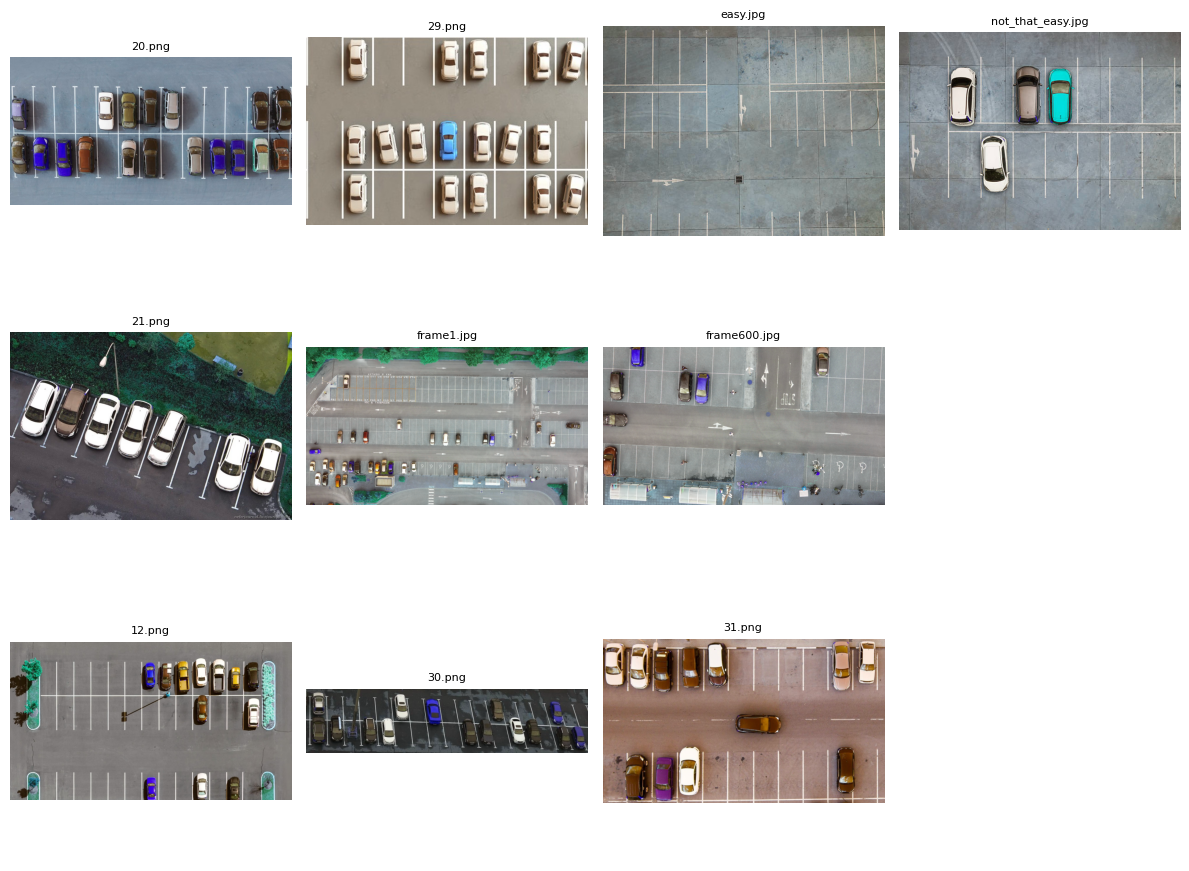


Processing set: easy

--- Running pipeline on 29.png ---
✔ Finished 29.png — boxes kept: 24

--- Running pipeline on not_that_easy.jpg ---
✔ Finished not_that_easy.jpg — boxes kept: 14

--- Running pipeline on easy.jpg ---
✔ Finished easy.jpg — boxes kept: 14

--- Running pipeline on 20.png ---
✔ Finished 20.png — boxes kept: 26

Processing set: medium

--- Running pipeline on 12.png ---
✔ Finished 12.png — boxes kept: 39

--- Running pipeline on 30.png ---
✔ Finished 30.png — boxes kept: 34

--- Running pipeline on 31.png ---
✔ Finished 31.png — boxes kept: 18

Processing set: hard

--- Running pipeline on 21.png ---
✔ Finished 21.png — boxes kept: 8

--- Running pipeline on frame600.jpg ---
✔ Finished frame600.jpg — boxes kept: 35

--- Running pipeline on frame1.jpg ---
✔ Finished frame1.jpg — boxes kept: 147


In [212]:
def do_pipeline(all_loaded_images, debug=False):

    results = {}

    for set_name, imgs in all_loaded_images.items():
        print(f"\n==============================")
        print(f"Processing set: {set_name}")
        print(f"==============================")

        results[set_name] = {}

        for fname, image in imgs.items():
            print(f"\n--- Running pipeline on {fname} ---")

            try:
                
                # Adding in some logic to fix big dangan
                params = get_params(set_name, fname)
                
                # ------------------------------------
                # STEP 1 — CANNY + GREY
                # ------------------------------------
                canny_output, grey_img = step_1(image)

                # ------------------------------------
                # STEP 2 — HOUGH PROBABILISTIC
                # ------------------------------------
                linesP = step_2(canny_output, image)

                # ------------------------------------
                # STEP 3 — FILTER BY MODAL ANGLE
                # ------------------------------------
                filtered_lines_step3, modal_angle_of_image = step_3(linesP, image)

                # ------------------------------------
                # STEP 4 — ROTATION
                # ------------------------------------
                rotation_angle_deg = np.rad2deg(modal_angle_of_image)
                rotated_image, M = rotate_image_nocrop(
                    image,
                    rotation_angle_deg,
                    threshold_deg=2
                )

                rotated_segments = rotate_points_step_4(filtered_lines_step3, M)

                # ------------------------------------
                # STEP 5 — MERGE BY MIDPOINT
                # ------------------------------------
                merged = merge_by_midpoint(rotated_segments, merge_radius=30)
                merged_filtered = [
                    (x1,y1,x2,y2)
                    for (x1,y1,x2,y2) in merged
                    if np.hypot(x2-x1, y2-y1) >= 50
                ]

                # ------------------------------------
                # STEP 6 — FILTER AGAIN BY ANGLE
                # ------------------------------------
                further_filtered_lines, modal_angle_of_image2 = filter_by_modal_angle(
                    rotated_segments,
                    angle_tolerance_deg=20
                )

                # ------------------------------------
                # STEP 7 — FINAL MERGE
                # ------------------------------------
                final_lines = final_merge_step([
                    (x1,y1,x2,y2)
                    for (_,_,x1,y1,x2,y2) in further_filtered_lines
                ])

                # ------------------------------------
                # STEP 8 — FILTER SHORT LINES
                # ------------------------------------
                filtered_lines2, modal_length = filter_short_lines_by_modal_length(final_lines)

                # ------------------------------------
                # STEP 9 — CLUSTER ROWS
                # ------------------------------------
                clusters, row_lines = cluster_rows_simple(filtered_lines2, modal_length, jump_factor=params["cluster_jump_factor"])

                # ------------------------------------
                # STEP 10 — MERGE ROW SEGMENTS
                # ------------------------------------
                final_row_sets = [merge_row_segments(r) for r in clusters]

                # ------------------------------------
                # STEP 11 — BUILD BOXES
                # ------------------------------------
                rows_of_boxes = []
                all_boxes = []
                for merged_row in final_row_sets:
                    row_boxes = build_boxes_connecting_lines(merged_row)
                    rows_of_boxes.append(row_boxes)
                    all_boxes.extend(row_boxes)
                
                # >>> FIX: force box points to be scalar floats (prevents int(array) crashes)
                rows_of_boxes = sanitise_rows_of_boxes(rows_of_boxes)
                all_boxes = sanitise_boxes(all_boxes)
                
                # ------------------------------------
                # STEP 12 — UNREFINED MODAL WIDTH
                # ------------------------------------
                unrefined_modal_width, _ = modal_box_spacing(all_boxes)
                
                # ------------------------------------
                # STEP 13 — BUILD HOUGH + HARRIS POINTS
                # ------------------------------------
                hough_points = []
                for (_, _, x1, y1, x2, y2) in rotated_segments:
                    hough_points.append((int(x1), int(y1)))
                    hough_points.append((int(x2), int(y2)))
                
                grey32 = np.float32(grey_img)
                harris = cv2.cornerHarris(grey32, blockSize=2, ksize=3, k=0.04)
                harris = cv2.dilate(harris, None)
                thresh = 0.01 * harris.max()
                raw_pts = np.argwhere(harris > thresh)
                harris_points = [(int(x), int(y)) for (y, x) in raw_pts]
                
                rotated_harris_points = rotate_points_xy_generic(harris_points, M)
                combined_points = hough_points + rotated_harris_points
                
                # ------------------------------------
                # STEP 14 — REFINE BOXES
                # ------------------------------------
                refined_rows = refine_boxes_with_hough_points(
                    rows_of_boxes,
                    combined_points,
                    max_shift_x=50,
                    slope_threshold=20,
                    modal_width=unrefined_modal_width
                )
                
                # >>> FIX: sanitise refined outputs as well (refinement may introduce arrays)
                refined_rows = sanitise_rows_of_boxes(refined_rows)
                refined_boxes = sanitise_boxes([box for row in refined_rows for box in row])
                
                # ------------------------------------
                # STEP 15 — UPDATED MODAL WIDTH
                # ------------------------------------
                modal_width, _ = modal_box_spacing(refined_boxes)


                # ------------------------------------
                # STEP 16 — FILTER BY WIDTH
                # ------------------------------------
                filtered_rows, removed_rows = filter_rows_of_boxes(
                    refined_rows,
                    modal_width,
                    tolerance=params["filter_tolerance"],
                    multi_box_thresh=params["filter_multi_box_thresh"],
                    debug=False
                )
                
                # >>> FIX: sanitise filtered boxes too
                filtered_rows = sanitise_rows_of_boxes(filtered_rows)
                filtered_boxes = sanitise_boxes([b for row in filtered_rows for b in row])
                
                # ------------------------------------
                # STEP 17 — SPLIT DOUBLE-HEIGHT BOXES
                # ------------------------------------
                split_boxes = split_double_height_boxes(
                    filtered_boxes,
                    modal_width,
                    threshold=params["split_threshold"],  # set to 0 for dangan
                    debug=False
                )
                
                # >>> FIX: sanitise post-split (splitting uses interpolation → floats)
                split_boxes = sanitise_boxes(split_boxes)
                
                # ------------------------------------
                # STEP 18 — REMOVE SHORT/SKEWED BOXES
                # ------------------------------------
                kept_boxes, removed_boxes2 = remove_short_boxes(
                    split_boxes,
                    modal_width,
                    debug=False
                )
                
                # >>> FIX: final safety sanitise
                kept_boxes = sanitise_boxes(kept_boxes)
                
                vis, occ_items, occ_debug = classify_and_draw_occupancy(rotated_image, kept_boxes)

                # ------------------------------------
                # SAVE RESULT FOR THIS IMAGE (single assignment)
                # ------------------------------------
                results[set_name][fname] = {
                    "modal_width": modal_width,
                    "boxes": kept_boxes,
                    "rotated_image": rotated_image,
                    "rows_of_boxes": rows_of_boxes,
                    "occupancy": occ_items,
                    "occupancy_vis": vis,
                    "occupancy_debug": occ_debug,  # optional, remove if you don't want it
                }

                print(f"✔ Finished {fname} — boxes kept: {len(kept_boxes)}")

            except Exception as e:
                print(f"❌ ERROR processing {fname}: {e}")
                traceback.print_exc()
                results[set_name][fname] = {"error": str(e)}


    return results


print_pics(loaded_images)
results = do_pipeline(loaded_images, debug=False)

In [213]:
                # filtered_rows, removed_rows = filter_rows_of_boxes(
                #     refined_rows,
                #     modal_width,
                #     tolerance=0.3,
                #     multi_box_thresh=0.15,
                #     debug=False
                # )

# clusters, row_lines = cluster_rows_simple(filtered_lines2, modal_length, jump_factor=0.8) # 0.5 for the hard Dangan one. 0.8 for the rest.

                # split_boxes = split_double_height_boxes(
                #     filtered_boxes,
                #     modal_width,
                #     threshold=0.18, # make this 0 for dangan
                #     debug=False
                # )



 SET: EASY


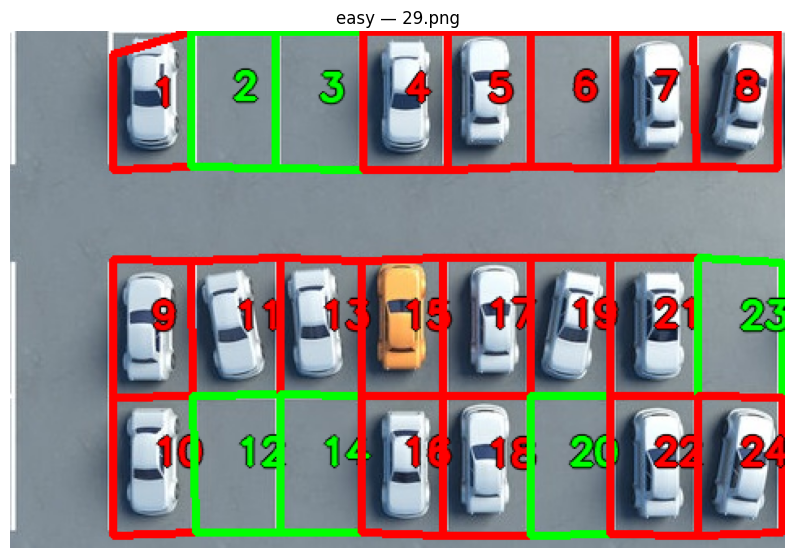

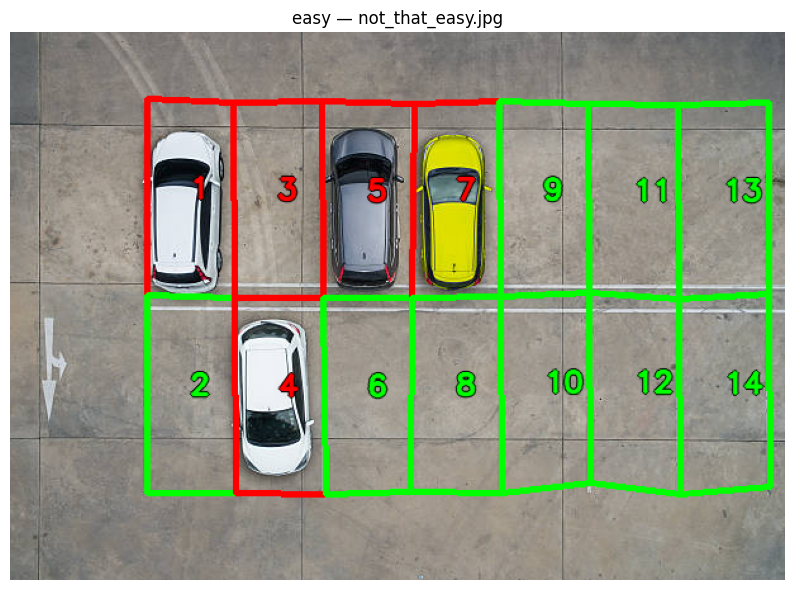

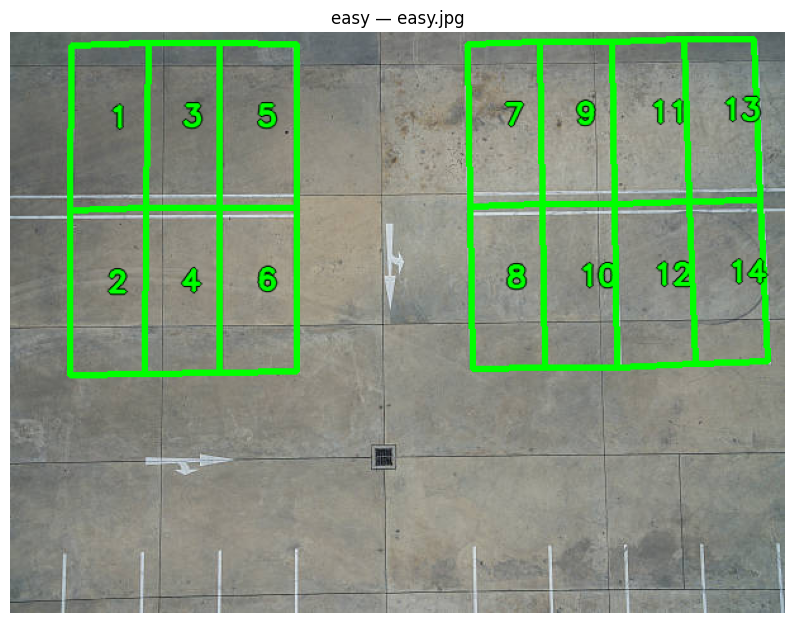

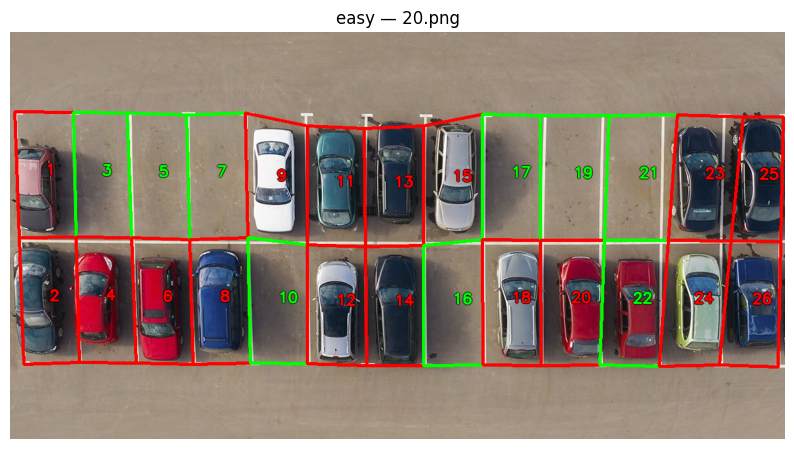


 SET: MEDIUM


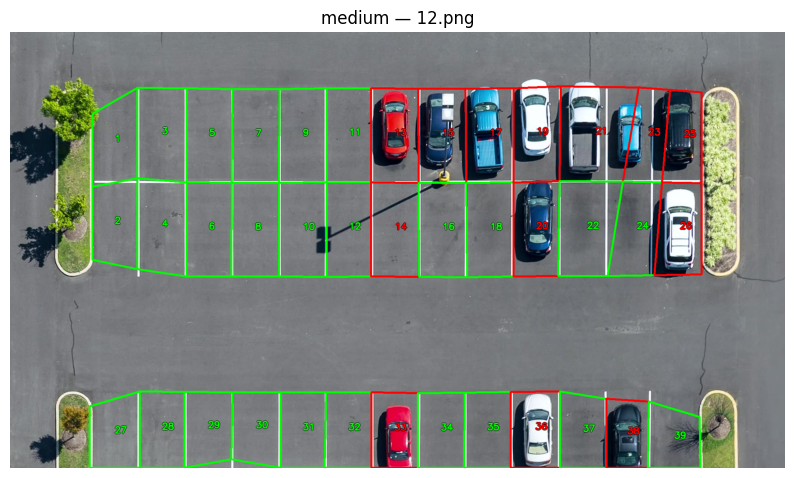

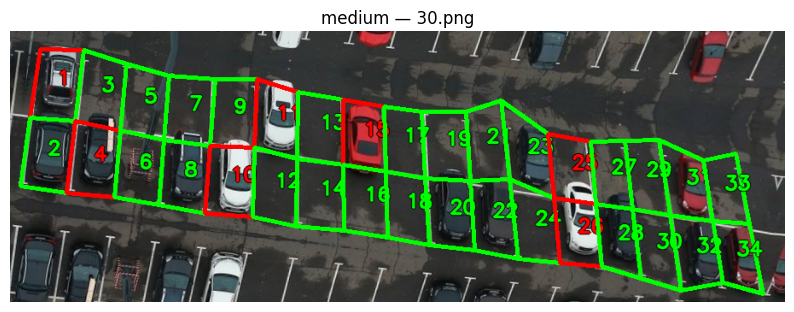

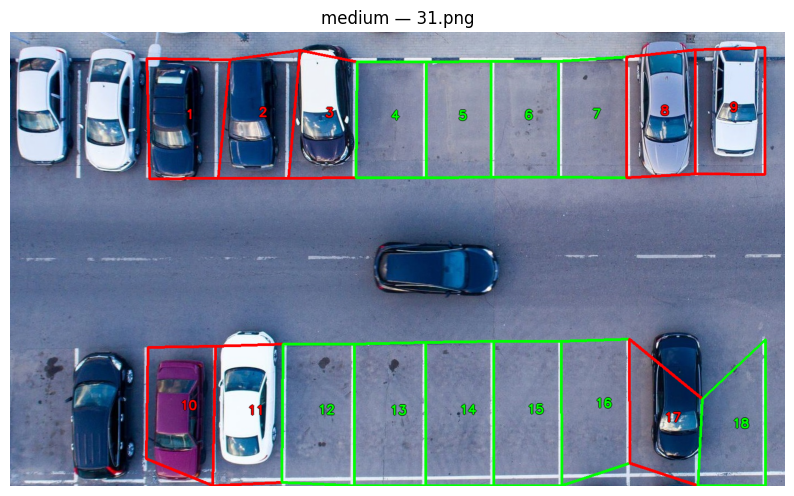


 SET: HARD


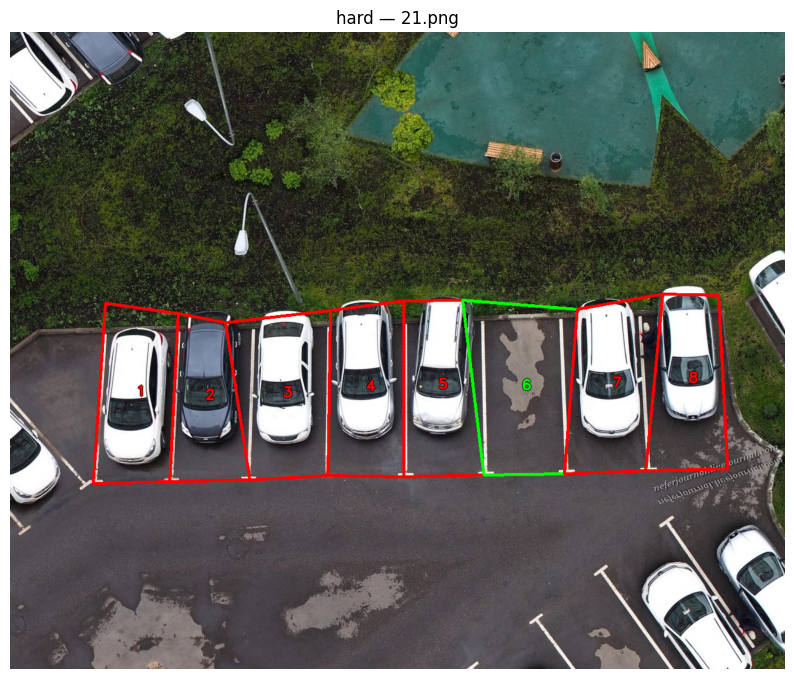

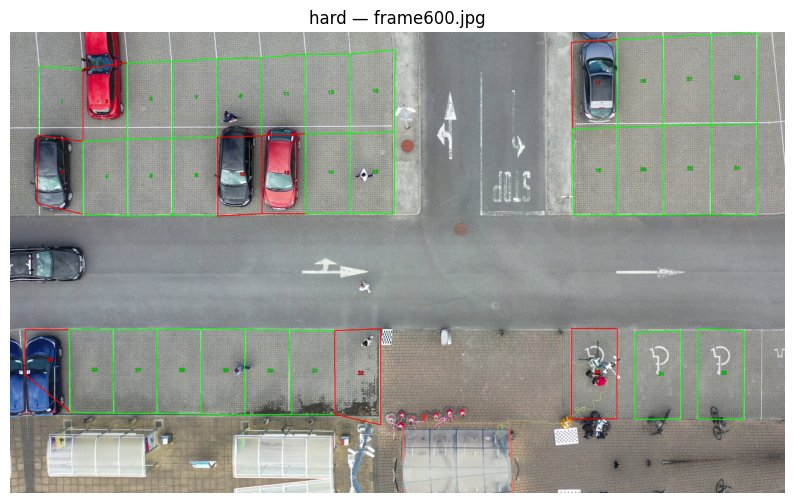

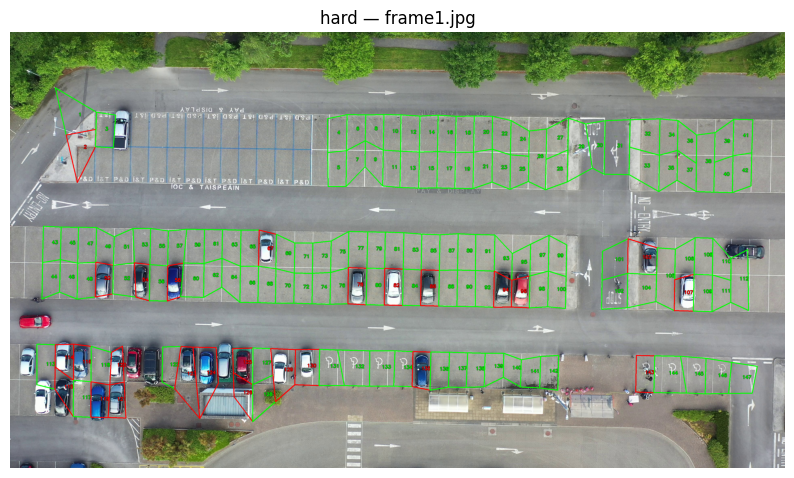

In [214]:
def show_occupancy_by_set(results, figsize=(10, 10)):
    """
    Iterates over all sets and images in `results`,
    displaying the occupancy-annotated output grouped by set.

    Assumes each image entry contains:
        results[set_name][fname]["occupancy_vis"]
    """

    for set_name, imgs in results.items():

        print("\n===================================")
        print(f" SET: {set_name.upper()}")
        print("===================================")

        for fname, data in imgs.items():

            if "occupancy_vis" not in data:
                print(f"⚠️  {fname}: no occupancy result")
                continue

            vis = data["occupancy_vis"]

            plt.figure(figsize=figsize)
            plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
            plt.title(f"{set_name} — {fname}")
            plt.axis("off")
            plt.show()


# ------------------------------
# Run visualization
# ------------------------------
show_occupancy_by_set(results)